# Pull yfinance data and wrangle it

In [20]:
import importlib
import vectorbt as vbt
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import theme
from src.utils.db import Db, postgres_context
from typing import cast

db = Db("pd-yfinance")
dfs = {}

### Pull data

In [2]:
pairs = ["BTC-USD"]
close = vbt.YFData.download(
    pairs[0],
    interval="1m",
    start="2025-04-12 09:30:00 -0400",
    end="2025-04-12 12:35:00 -0400",
).get("Close")
close

/tmp/ipykernel_24998/4167619899.py:2: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  close = vbt.YFData.download(


Datetime
2025-04-12 13:30:00+00:00    83791.445312
2025-04-12 13:31:00+00:00    83726.773438
2025-04-12 13:32:00+00:00    83742.960938
2025-04-12 13:33:00+00:00    83769.281250
2025-04-12 13:34:00+00:00    83745.085938
                                 ...     
2025-04-12 16:30:00+00:00    84949.015625
2025-04-12 16:31:00+00:00    84957.062500
2025-04-12 16:32:00+00:00    84905.164062
2025-04-12 16:33:00+00:00    84838.914062
2025-04-12 16:34:00+00:00    84801.257812
Name: Close, Length: 177, dtype: float64

In [3]:
# TODO anki
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

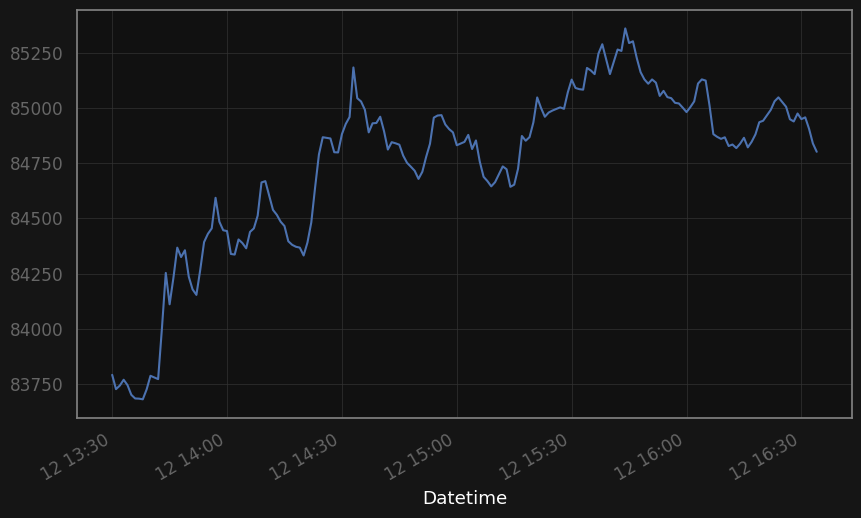

In [4]:
# ADD TO ANKI
importlib.reload(theme)
#
with plt.style.context(theme.vscode_dark):
    fig, ax = plt.subplots()
    close.plot(ax=ax)
    plt.show()

## Insert into db

## Insert one

In [5]:
db.exec("create.table")
for ts, c in close.items():
    db.exec("insert.one", (ts, c))

## Insert with procedure

In [43]:
db.exec("create.table2")
db.exec("procedure.insert")

In [ ]:
# TODO ANKI
db.exec("insert.procedure", [list(close.copy().items())])

## Select all

In [2]:
usd = pd.DataFrame(db.select("all"), columns=["id", "ts", "close"]).set_index(
    "id"
)
usd

,ts,close
id,,
1,2025-04-12 13:30:00+00:00,83791.445312
2,2025-04-12 13:31:00+00:00,83726.773438
3,2025-04-12 13:32:00+00:00,83742.960938
4,2025-04-12 13:33:00+00:00,83769.281250
5,2025-04-12 13:34:00+00:00,83745.085938
...,...,...
173,2025-04-12 16:30:00+00:00,84949.015625
174,2025-04-12 16:31:00+00:00,84957.062500
175,2025-04-12 16:32:00+00:00,84905.164062


In [81]:
import re

db.exec("function.tumble")
db.view_select(
    dfs,
    "view.tumble-5-2",
    columns=["Id", "Window", "RowNumber", "Timestamp", "ClosePrice"],
    index=["Window", "Id"],
)
dfs["view.tumble-5-2"]["raw"]
with pd.option_context("display.max_rows", None):
    html = dfs["view.tumble-5-2"]["raw"].head(5).to_html()
    display(re.sub(r">\s+<", "><", html))
    display(dfs["view.tumble-5-2"]["raw"].head(5))

'<table border="1" class="dataframe"><thead><tr style="text-align: right;"><th></th><th></th><th>ClosePrice</th><th>RowNumber</th><th>Timestamp</th></tr><tr><th>Window</th><th>Id</th><th></th><th></th><th></th></tr></thead><tbody><tr><th rowspan="2" valign="top">2025-04-12 13:27:00+00:00</th><th>1</th><td>83791.445312</td><td>1</td><td>2025-04-12 13:30:00+00:00</td></tr><tr><th>2</th><td>83726.773438</td><td>2</td><td>2025-04-12 13:31:00+00:00</td></tr><tr><th rowspan="3" valign="top">2025-04-12 13:32:00+00:00</th><th>3</th><td>83742.960938</td><td>1</td><td>2025-04-12 13:32:00+00:00</td></tr><tr><th>4</th><td>83769.281250</td><td>2</td><td>2025-04-12 13:33:00+00:00</td></tr><tr><th>5</th><td>83745.085938</td><td>3</td><td>2025-04-12 13:34:00+00:00</td></tr></tbody></table>'

ClosePrice  RowNumber  \
Window                    Id                            
2025-04-12 13:27:00+00:00 1   83791.445312          1   
                          2   83726.773438          2   
2025-04-12 13:32:00+00:00 3   83742.960938          1   
                          4   83769.281250          2   
                          5   83745.085938          3   

                                             Timestamp  
Window                    Id                            
2025-04-12 13:27:00+00:00 1  2025-04-12 13:30:00+00:00  
                          2  2025-04-12 13:31:00+00:00  
2025-04-12 13:32:00+00:00 3  2025-04-12 13:32:00+00:00  
                          4  2025-04-12 13:33:00+00:00  
                          5  2025-04-12 13:34:00+00:00

In [82]:
dfs["view.tumble-5-2"]["raw"].columns

Index(['ClosePrice', 'RowNumber', 'Timestamp'], dtype='object')

In [45]:
dfs["view.tumble-5-2"]["ordered"] = dfs["view.tumble-5-2"]["raw"][
    ["RowNumber", "Timestamp", "ClosePrice"]
]
html = dfs["view.tumble-5-2"]["ordered"].head(5).to_html()
with pd.option_context("display.expand_frame_repr", None):
    print(dfs["view.tumble-5-2"]["ordered"].head(5))

KeyError: 'view.tumble-5-2'

In [90]:
dfs["view.tumble-5-2"]["describe"] = (
    dfs["view.tumble-5-2"]["ordered"].groupby("Window").describe()
)
with pd.option_context("display.expand_frame_repr", None):
    print(dfs["view.tumble-5-2"]["describe"].head(5))

                          RowNumber                                           ClosePrice                                                                                                
                              count mean       std  min   25%  50%   75%  max      count          mean         std           min           25%           50%           75%           max
Window                                                                                                                                                                                  
2025-04-12 13:27:00+00:00       2.0  1.5  0.707107  1.0  1.25  1.5  1.75  2.0        2.0  83759.109375   45.729921  83726.773438  83742.941406  83759.109375  83775.277344  83791.445312
2025-04-12 13:32:00+00:00       5.0  3.0  1.581139  1.0  2.00  3.0  4.00  5.0        5.0  83728.585938   34.759618  83684.531250  83701.070312  83742.960938  83745.085938  83769.281250
2025-04-12 13:37:00+00:00       4.0  2.5  1.290994  1.0  1.75  2.5  3.25  4

In [ ]:
# ANKI DONE

df = dfs["view.tumble-5-2"]["describe"].copy()
df.columns = [":".join(col).strip() for col in df.columns.values]

melted = df.reset_index().melt(
    id_vars=["Window"],
    var_name="Feature:Stat",
    value_name="Value",
)

melted[["Feature", "Stat"]] = melted["Feature:Stat"].str.rsplit(
    ":", n=1, expand=True
)

tidy = (
    melted.copy()
    .pivot(
        index=["Window", "Stat"],
        columns="Feature",
        values="Value",
    )
    .reset_index()
    .drop(columns=["RowNumber"])
    .rename(
        columns={
            "ClosePrice": "Value",
        }
    )
)
tidy = tidy.set_index("Window")

# with pd.option_context("display.expand_frame_repr", None):
#     print(tidy.head(10))

with pd.option_context("display.max_rows", None):
    display(
        tidy.style.format(
            {
                "Parity": "{:.4f}",
            }
        )
    )

Feature,Stat,Value
Window,,
2025-04-12 13:27:00+00:00,25%,83742.941406
2025-04-12 13:27:00+00:00,50%,83759.109375
2025-04-12 13:27:00+00:00,75%,83775.277344
2025-04-12 13:27:00+00:00,count,2.000000
2025-04-12 13:27:00+00:00,max,83791.445312
2025-04-12 13:27:00+00:00,mean,83759.109375
2025-04-12 13:27:00+00:00,min,83726.773438
2025-04-12 13:27:00+00:00,std,45.729921
2025-04-12 13:32:00+00:00,25%,83701.070312
